# Tech Challenge: Classificando a qualidade de vinhos com Machine Learning

Este notebook atende ao desafio de prever a qualidade de
um vinho com base em suas características físico-químicas.
- Quality >= 7: Vinho de alta qualidade.
- Quality < 7: Vinho de baixa/média qualidade.

## 1. Compreensão do Problema

- Variável alvo original: quality
- Transformação binária: quality_binary = 1 se quality >= 7, senão 0
- Objetivo: Treinar e avaliar modelos de aprendizado de máquina capazes de prever essa classificação a partir das variáveis disponíveis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    )

# Configura estilo dos gráficos para melhorar legibilidade.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

In [4]:
# Leitura do dataset de vinhos.
df = pd.read_csv('./data/winequality-red.csv', sep=';')
if 'quality' not in df.columns:
    df = pd.read_csv('./data/winequality-red.csv')

# Transforma a qualidade original em alvo binário:
# 1 = alta qualidade (quality >= 7), 0 = baixa/media (quality < 7).
df['quality_binary'] = (df['quality'] >= 7).astype(int)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


In [5]:
#Números representando  a dimensionalidade do conjunto de dados
df.shape

(1143, 14)

## 2. Análise Exploratória de Dados (EDA)



Dimensão da base (linhas, colunas): (1143, 14)

Quantidade de valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
quality_binary          0
dtype: int64


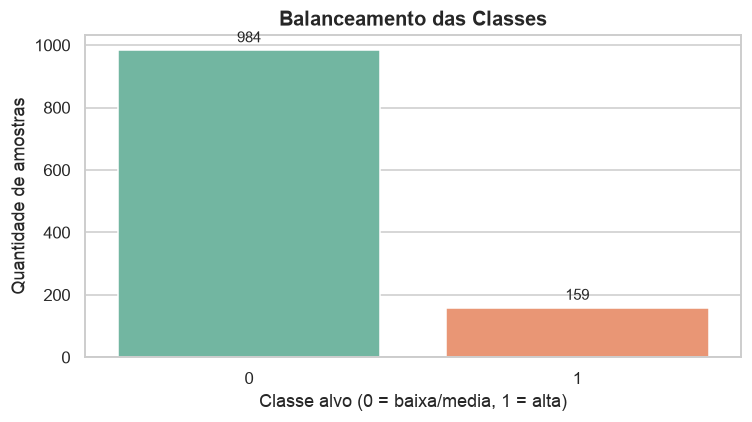


Interpretação do gráfico:
- Classe 0 (baixa/media): 86.1%
- Classe 1 (alta): 13.9%
- Quanto mais desbalanceadas as barras, maior o cuidado na avaliação dos modelos.


In [11]:
# Visão geral da base.
print('Dimensão da base (linhas, colunas):', df.shape)
print('\nQuantidade de valores nulos por coluna:')
print(df.isnull().sum())

# Gráfico 1: balanceamento das classes.
# Ele mostra quantos vinhos há em cada classe do alvo binário.
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='quality_binary', hue='quality_binary', palette='Set2', legend=False)
ax.set_title('Balanceamento das Classes', fontsize=13, weight='bold')
ax.set_xlabel('Classe alvo (0 = baixa/media, 1 = alta)')
ax.set_ylabel('Quantidade de amostras')

# Adiciona os valores no topo de cada barra para leitura imediata.
for p in ax.patches:
    altura = int(p.get_height())
    ax.annotate(
        f'{altura}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('./images/balanceamento_classes.png', dpi=300, bbox_inches='tight')
plt.show()

proporcao = df['quality_binary'].value_counts(normalize=True).sort_index()
print('\nInterpretação do gráfico:')
print(f"- Classe 0 (baixa/media): {proporcao.loc[0]*100:.1f}%")
print(f"- Classe 1 (alta): {proporcao.loc[1]*100:.1f}%")
print('- Quanto mais desbalanceadas as barras, maior o cuidado na avaliação dos modelos.')

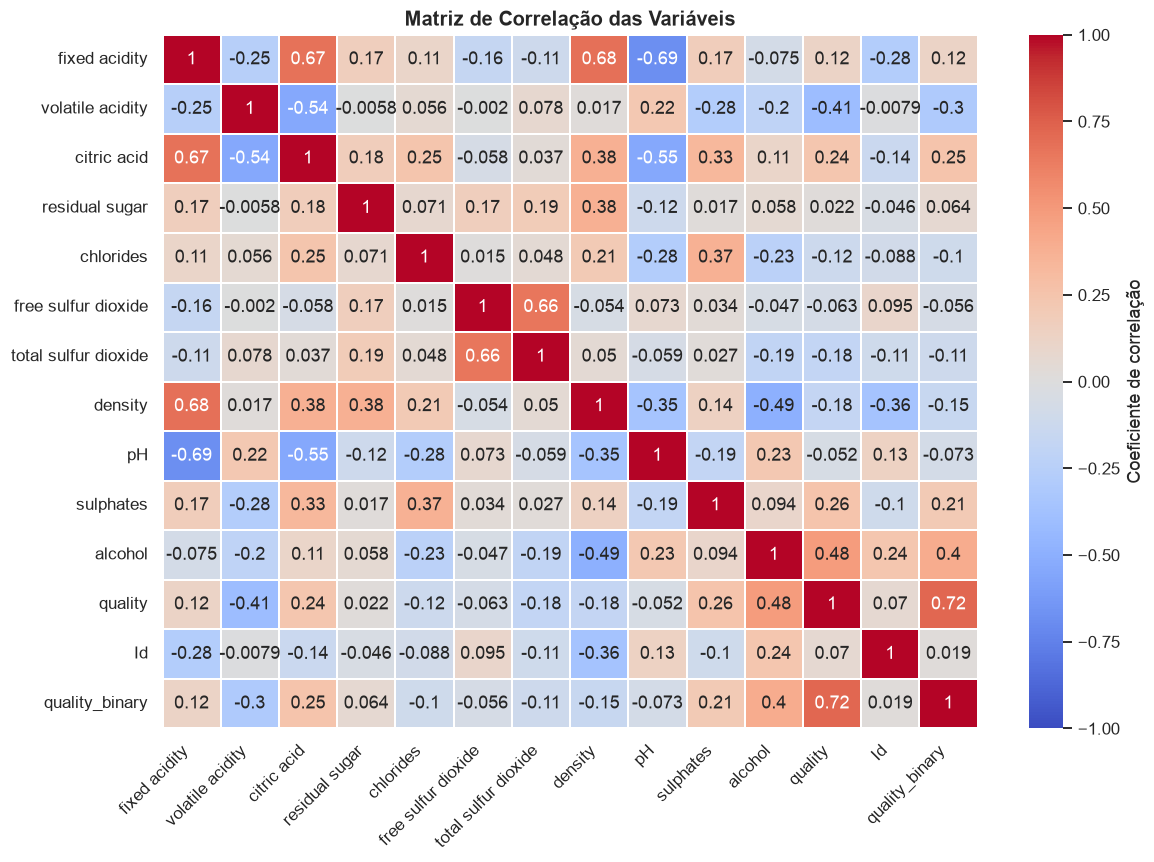

Interpretação do gráfico (top 6 correlações com qualidade_binary):
- quality: correlação positiva (0.720)
- alcohol: correlação positiva (0.404)
- volatile acidity: correlação negativa (-0.305)
- citric acid: correlação positiva (0.251)
- sulphates: correlação positiva (0.208)
- density: correlação negativa (-0.149)

Leitura rápida: valores mais próximos de +1 ou -1 indicam relação mais forte com a classe alvo.


In [10]:
# Gráfico 2: mapa de calor de correlações entre variáveis numéricas.
# Cores próximas de vermelho = correlação positiva forte.
# Cores próximas de azul = correlação negativa forte.
corr = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
ax = sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    linewidths=0.3,
    cbar_kws={'label': 'Coeficiente de correlação'}
)
ax.set_title('Matriz de Correlação das Variáveis', fontsize=13, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('./images/matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

# Mostra automaticamente as correlações mais fortes com o alvo para facilitar interpretação.
corr_alvo = corr['quality_binary'].drop('quality_binary').sort_values(key=np.abs, ascending=False)
print('Interpretação do gráfico (top 6 correlações com qualidade_binary):')
for nome, valor in corr_alvo.head(6).items():
    direcao = 'positiva' if valor >= 0 else 'negativa'
    print(f'- {nome}: correlação {direcao} ({valor:.3f})')

print('\nLeitura rápida: valores mais próximos de +1 ou -1 indicam relação mais forte com a classe alvo.')